<a href="https://colab.research.google.com/github/santhoshreddynarra/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Required Libraries


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# visualization settings
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## Load Data

In [ ]:
data = pd.read_csv("/content/creditcard.csv")

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
data.count()


,0
Time,284807
V1,284807
V2,284807
V3,284807
V4,284807
V5,284807
V6,284807
V7,284807
V8,284807
V9,284807


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Exploratory Data Analysis

##Univariate Analysis

In [ ]:
data.isnull().values.any()

np.False_

In [ ]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Drop rows with any null values
#data = data.dropna()
#data.isnull().sum()

In [ ]:
## Get the Fraud and the normal dataset

fraud = data[data['Class']==1]
normal = data[data['Class']==0]

In [ ]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
normal.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


# Bivariate Analysis

##Amount Distribution by Class

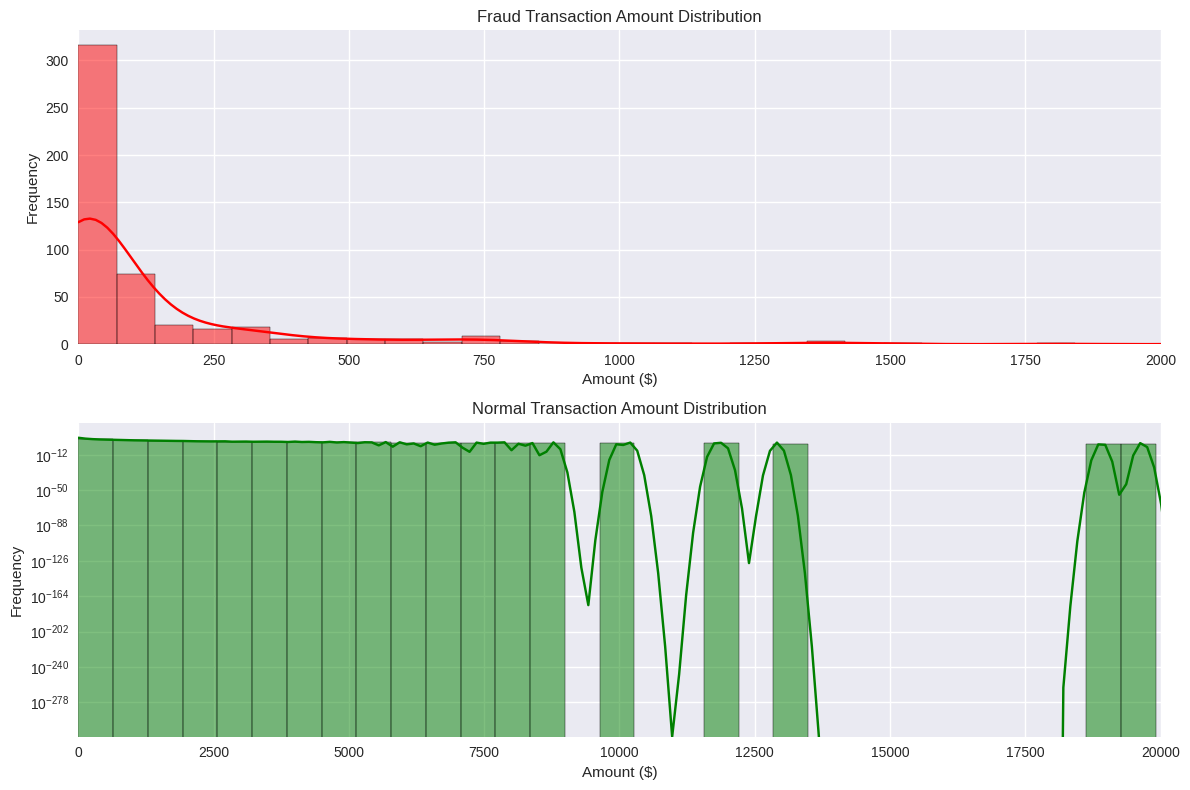

In [ ]:
plt.figure(figsize=(12, 8))

# Fraud
plt.subplot(2, 1, 1)
sns.histplot(fraud["Amount"], bins=30, kde=True, color="red")
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount ($)")
plt.ylabel("Frequency")
plt.xlim(0, 2000)

# Normal
plt.subplot(2, 1, 2)
sns.histplot(normal["Amount"], bins=40, kde=True, color="green")
plt.title("Normal Transaction Amount Distribution")
plt.xlabel("Amount ($)")
plt.ylabel("Frequency")
plt.xlim(0, 20000)
plt.yscale("log")

plt.tight_layout()
plt.show()


##Time vs Amount by Class

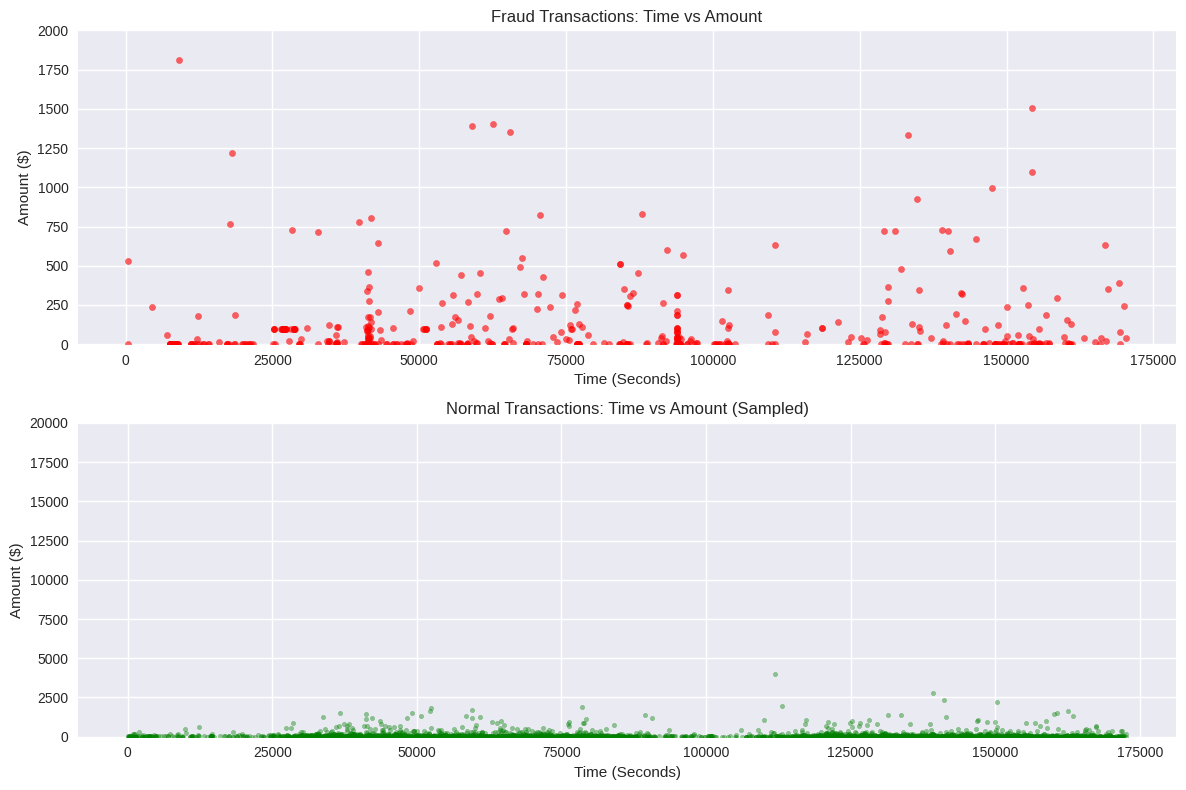

In [ ]:
plt.figure(figsize=(12, 8))

# Fraud
plt.subplot(2, 1, 1)
plt.scatter(fraud.Time, fraud.Amount, alpha=0.6, s=20, color="red")
plt.title("Fraud Transactions: Time vs Amount")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amount ($)")
plt.ylim(0, 2000)

# Normal (sample for clarity)
normal_sample = normal.sample(3000, random_state=42)

plt.subplot(2, 1, 2)
plt.scatter(normal_sample.Time, normal_sample.Amount, alpha=0.4, s=10, color="green")
plt.title("Normal Transactions: Time vs Amount (Sampled)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amount ($)")
plt.ylim(0, 20000)

plt.tight_layout()
plt.show()

# Checking Class Imbalance

In [ ]:
data.shape

(284807, 31)

In [ ]:
print("Fraud Shape:",fraud.shape)
print("Normal Shape:",normal.shape)

Fraud Shape: (492, 31)
Normal Shape: (284315, 31)


In [ ]:
print("Percentage of Fraud: {:.4f}%".format(len(fraud)/data.shape[0]*100))
print("Percentage of Normal: {:.4f}%".format(len(normal)/data.shape[0]*100))

Percentage of Fraud: 0.1727%
Percentage of Normal: 99.8273%


In [ ]:
#calculating class imbalance
class_imbalance = len(fraud)/float(len(normal))

In [ ]:
print("Class Imbalance :",class_imbalance)

Class Imbalance : 0.0017304750013189597


/tmp/ipykernel_8165/2531824620.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort = True)


Text(0, 0.5, 'Frequency')

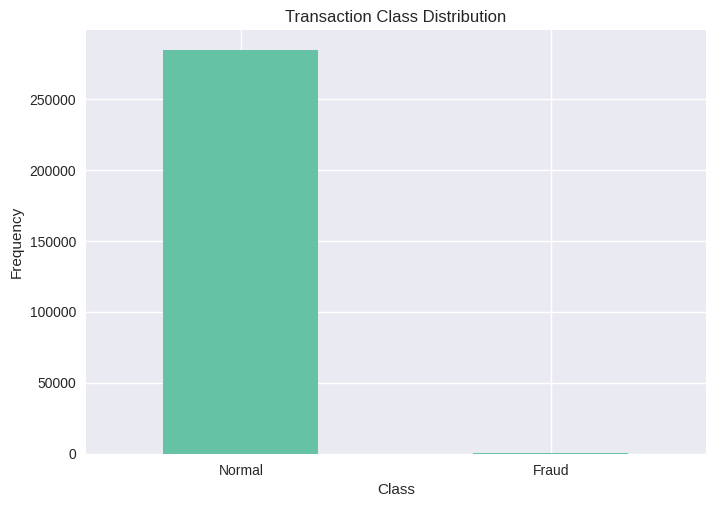

In [ ]:
count_classes = pd.value_counts(data['Class'], sort = True)
Labels = ["Normal", "Fraud"]
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), Labels)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    auc
)

sns.set(style="whitegrid")




In [ ]:
df=pd.read_csv("/content/creditcard.csv")

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

# X = all columns except "Class"
X = df.drop("Class", axis=1)

# y = target column
y = df["Class"]

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (284807, 30)
Target shape (y): (284807,)


In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y            # preserves class distribution
)

In [ ]:
print("\nTrain set shape (X_train):", X_train.shape)
print("Test set shape  (X_test):", X_test.shape)


# Check class distribution in train and test sets
print("\nClass distribution in y_train (counts):")
print(y_train.value_counts())

print("\nClass distribution in y_train (percentage):")
print((y_train.value_counts(normalize=True) * 100).round(4))

print("\nClass distribution in y_test (counts):")
print(y_test.value_counts())

print("\nClass distribution in y_test (percentage):")
print((y_test.value_counts(normalize=True) * 100).round(4))


Train set shape (X_train): (227845, 30)
Test set shape  (X_test): (56962, 30)

Class distribution in y_train (counts):
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution in y_train (percentage):
Class
0    99.8271
1     0.1729
Name: proportion, dtype: float64

Class distribution in y_test (counts):
Class
0    56864
1       98
Name: count, dtype: int64

Class distribution in y_test (percentage):
Class
0    99.828
1     0.172
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
# Create copies of X_train and X_test to avoid modifying the original data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()


# Initialize the scaler
scaler = StandardScaler()


# Fit scaler ONLY on training data and transform both train and test

cols_to_scale = ["Time", "Amount"]

# Fit on training data
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform test data using the same scaler
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


# Show a quick comparison before/after scaling

print("Before Scaling (Train):")
print(X_train[cols_to_scale].head())

print("\nAfter Scaling (Train):")
print(X_train_scaled[cols_to_scale].head())

Before Scaling (Train):
            Time  Amount
265518  161919.0    7.32
180305  124477.0    2.99
42664    41191.0  175.10
198723  132624.0    6.10
82325    59359.0   86.10

After Scaling (Train):
            Time    Amount
265518  1.411588 -0.322494
180305  0.623141 -0.339764
42664  -1.130680  0.346693
198723  0.794699 -0.327360
82325  -0.748102 -0.008281


## Baseline Model - Logistic Regression  (Class-Weighted)
We handle imbalance data at the **algorithm level** using class weights.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Initialize Logistic Regression model
log_reg = LogisticRegression(
    class_weight="balanced",  # handle class imbalance by giving more weight to minority class
    max_iter=1000,
    n_jobs=-1,
    solver="lbfgs"
)

In [ ]:
# Train the model on the scaled training data
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [ ]:
# Make predictions on the test set
from sklearn.metrics import average_precision_score

y_pred_lr = log_reg.predict(X_test_scaled)             # predicted class labels (0 or 1)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1] # predicted probability of class 1 (fraud)

# Calculate PR-AUC
pr_auc_lr = average_precision_score(y_test, y_proba_lr)

In [ ]:
# Evaluate the model

# Classification report: precision, recall, f1-score per class
print("Classification Report - Logistic Regression (class_weight='balanced'):")
print(classification_report(y_test, y_pred_lr, digits=4))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix - Logistic Regression:")
print(cm_lr)

# PR-AUC Score
print("\nPR-AUC Score - Logistic Regression: {:.4f}".format(pr_auc_lr))

Classification Report - Logistic Regression (class_weight='balanced'):
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962

Confusion Matrix - Logistic Regression:
[[55478  1386]
 [    8    90]]

PR-AUC Score - Logistic Regression: 0.7159


In [ ]:
# ROC-AUC score using predicted probabilities
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
print("\nROC-AUC Score - Logistic Regression: {:.4f}".format(roc_auc_lr))


ROC-AUC Score - Logistic Regression: 0.9722


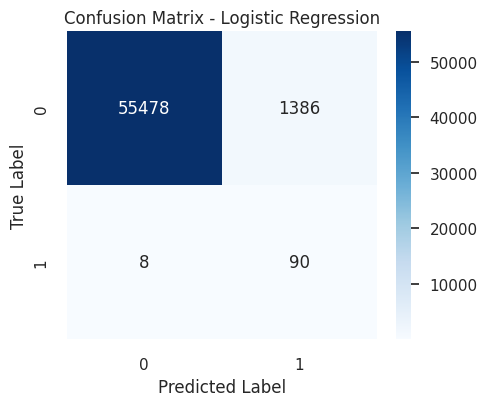

In [ ]:
# Evaluation Plots for Logistic Regression
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


# Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Random Forest

In [ ]:
#  Random Forest - class_weight="balanced"
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Initialize Random Forest model
rf_clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [ ]:
# Make predictions on the test set
y_pred_rf = rf_clf.predict(X_test)                 # predicted class labels
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]    # predicted probability of class 1 (fraud)

# Calculate PR-AUC
pr_auc_rf = average_precision_score(y_test, y_proba_rf)

In [ ]:
# Evaluate the model
print("Classification Report - Random Forest (class_weight='balanced'):")
print(classification_report(y_test, y_pred_rf, digits=4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix - Random Forest:")
print(cm_rf)

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print("\nROC-AUC Score - Random Forest: {:.4f}".format(roc_auc_rf))
print("PR-AUC Score - Random Forest: {:.4f}".format(pr_auc_rf))

Classification Report - Random Forest (class_weight='balanced'):
              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9997     56864
           1     0.7941    0.8265    0.8100        98

    accuracy                         0.9993     56962
   macro avg     0.8969    0.9131    0.9048     56962
weighted avg     0.9993    0.9993    0.9993     56962

Confusion Matrix - Random Forest:
[[56843    21]
 [   17    81]]

ROC-AUC Score - Random Forest: 0.9807
PR-AUC Score - Random Forest: 0.8056


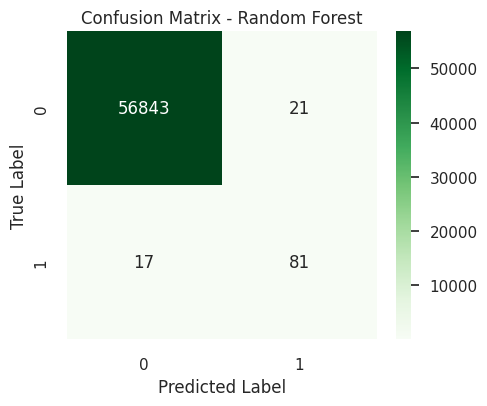

In [ ]:
# Evaluation Plots - Random Forest

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


# Confusion Matrix Heatmap


plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

###  Interpretation

- Random Forest Learns non-linear relationships
- Handles imbalance better using class weights
- **Precision jumps from 6% → 96%**
- Slight drop in recall compared to Logistic Regression

 Strong real-world candidate


#Model Building 2

## Oversampling + Random Forest
We now handle imbalance at the **data level** by oversampling fraud cases.


In [ ]:
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Combine X_train and y_train
train_data = X_train.copy()
train_data["Class"] = y_train.values

print("Original class distribution in training data:")
print(train_data["Class"].value_counts())

Original class distribution in training data:
Class
0    227451
1       394
Name: count, dtype: int64


In [ ]:
# Split into minority and majority classes

fraud_train = train_data[train_data["Class"] == 1]
non_fraud_train = train_data[train_data["Class"] == 0]

print("\nNumber of non-fraud samples in train:", len(non_fraud_train))
print("Number of fraud samples in train:", len(fraud_train))


Number of non-fraud samples in train: 227451
Number of fraud samples in train: 394


In [ ]:
fraud_oversampled = resample(
    fraud_train,
    replace=True,                      # sample with replacement
    n_samples=len(non_fraud_train),    # match majority class
    random_state=42
)

In [ ]:
# Create balanced training set
train_oversampled = pd.concat([non_fraud_train, fraud_oversampled])

# Shuffle rows
train_oversampled = train_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nClass distribution after oversampling:")
print(train_oversampled["Class"].value_counts())


Class distribution after oversampling:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
X_train_over = train_oversampled.drop("Class", axis=1)
y_train_over = train_oversampled["Class"]

In [ ]:
rf_over = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    class_weight=None,   # data is balanced now
    n_jobs=-1,
    random_state=42
)

rf_over.fit(X_train_over, y_train_over)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf_over = rf_over.predict(X_test)
y_proba_rf_over = rf_over.predict_proba(X_test)[:, 1]

# Calculate PR-AUC
pr_auc_rf_over = average_precision_score(y_test, y_proba_rf_over)

roc_auc_rf_over = roc_auc_score(y_test, y_proba_rf_over)

print("Classification Report - Oversampled Random Forest")
print(classification_report(y_test, y_pred_rf_over, digits=4))

cm_rf_over = confusion_matrix(y_test, y_pred_rf_over)
print("Confusion Matrix - Random Forest:")
print(cm_rf_over)


print("ROC-AUC Score - Oversampled Random Forest:",
      roc_auc_score(y_test, y_proba_rf_over))
print("PR-AUC Score - Oversampled Random Forest: {:.4f}".format(pr_auc_rf_over))

Classification Report - Oversampled Random Forest
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9620    0.7755    0.8588        98

    accuracy                         0.9996     56962
   macro avg     0.9808    0.8877    0.9293     56962
weighted avg     0.9995    0.9996    0.9995     56962

Confusion Matrix - Random Forest:
[[56861     3]
 [   22    76]]
ROC-AUC Score - Oversampled Random Forest: 0.953147430891321
PR-AUC Score - Oversampled Random Forest: 0.8514


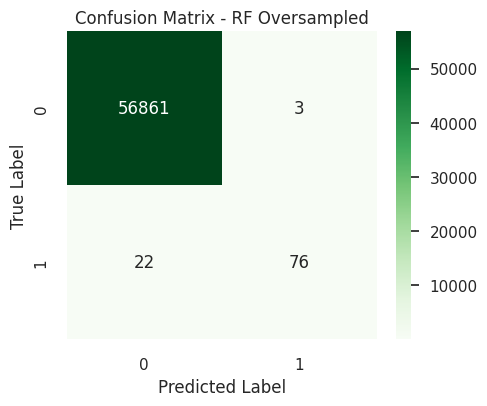

In [ ]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


# Confusion Matrix Heatmap
cm_rf_over = confusion_matrix(y_test, y_pred_rf_over)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf_over, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - RF Oversampled")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Calculate PR-AUC
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

In [ ]:
print("Classification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb))

cm_xgb_model = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix - Random Forest:")
print(cm_xgb_model)

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC Score - XGBoost: {:.4f}".format(pr_auc_xgb))

Classification Report - XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix - Random Forest:
[[56852    12]
 [   17    81]]
ROC-AUC Score: 0.9725846057331204
PR-AUC Score - XGBoost: 0.8791


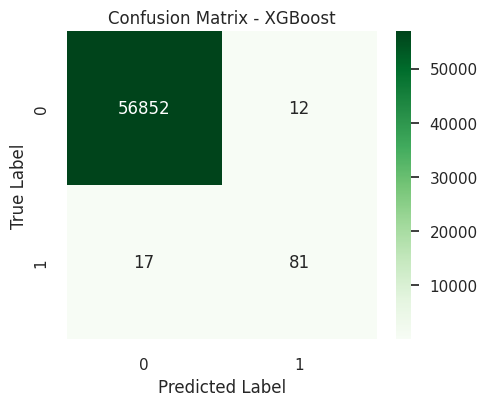

In [ ]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


# Confusion Matrix Heatmap
cm_xgb_model = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb_model, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## ROC Comparison

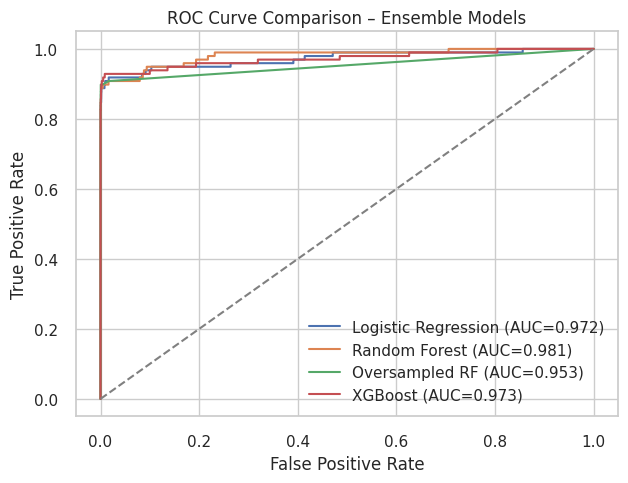

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

plt.figure(figsize=(7,5))

plot_roc(y_test, y_proba_lr, "Logistic Regression")
plot_roc(y_test, y_proba_rf, "Random Forest")
plot_roc(y_test, y_proba_rf_over, "Oversampled RF")
plot_roc(y_test, y_prob_xgb, "XGBoost")

plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – Ensemble Models")
plt.legend()
plt.grid(True)
plt.show()


### Precision-Recall Curves

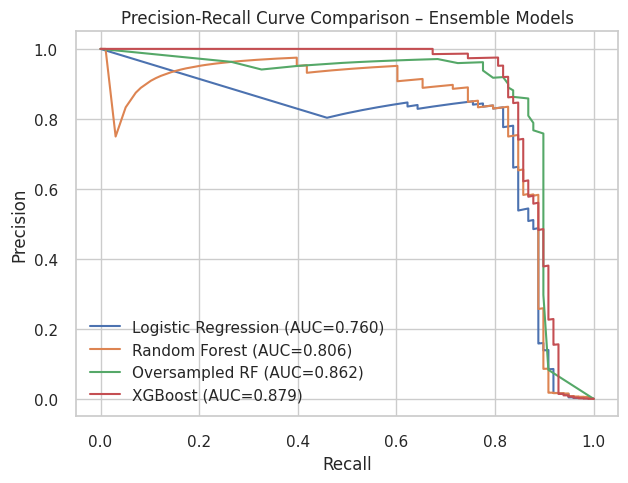

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

def plot_pr_curve(y_true, y_prob, label):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label} (AUC={pr_auc:.3f})")

plt.figure(figsize=(7,5))

plot_pr_curve(y_test, y_proba_lr, "Logistic Regression")
plot_pr_curve(y_test, y_proba_rf, "Random Forest")
plot_pr_curve(y_test, y_proba_rf_over, "Oversampled RF")
plot_pr_curve(y_test, y_prob_xgb, "XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison – Ensemble Models")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_fraud_metrics(y_true, y_pred):
    """
    Returns precision, recall, and f1-score for the FRAUD class (label = 1)
    """
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return precision, recall, f1


In [ ]:
lr_precision, lr_recall, lr_f1 = get_fraud_metrics(y_test, y_pred_lr)
rf_precision, rf_recall, rf_f1 = get_fraud_metrics(y_test, y_pred_rf)
rf_over_precision, rf_over_recall, rf_over_f1 = get_fraud_metrics(
    y_test, y_pred_rf_over
)
xgb_precision, xgb_recall, xgb_f1 = get_fraud_metrics(y_test, y_pred_xgb)


## Model Comparison

In [ ]:
comparison_data = {
    "Model": [
        "Logistic Regression (class_weight)",
        "Random Forest (class_weight)",
        "Random Forest + Oversampling",
        "XGBoost"
    ],
    "Precision (Fraud)": [
        lr_precision,
        rf_precision,
        rf_over_precision,
        xgb_precision
    ],
    "Recall (Fraud)": [
        lr_recall,
        rf_recall,
        rf_over_recall,
        xgb_recall
    ],
    "F1-score (Fraud)": [
        lr_f1,
        rf_f1,
        rf_over_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_rf_over,
        roc_auc_xgb
    ],
    "PR-AUC": [
        pr_auc_lr,
        pr_auc_rf,
        pr_auc_rf_over,
        pr_auc_xgb
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Precision (Fraud),Recall (Fraud),F1-score (Fraud),ROC-AUC,PR-AUC
0,Logistic Regression (class_weight),0.060976,0.918367,0.114358,0.972169,0.715912
1,Random Forest (class_weight),0.794118,0.826531,0.810000,0.980658,0.805557
2,Random Forest + Oversampling,0.962025,0.775510,0.858757,0.953147,0.851377
3,XGBoost,0.870968,0.826531,0.848168,0.972585,0.879055


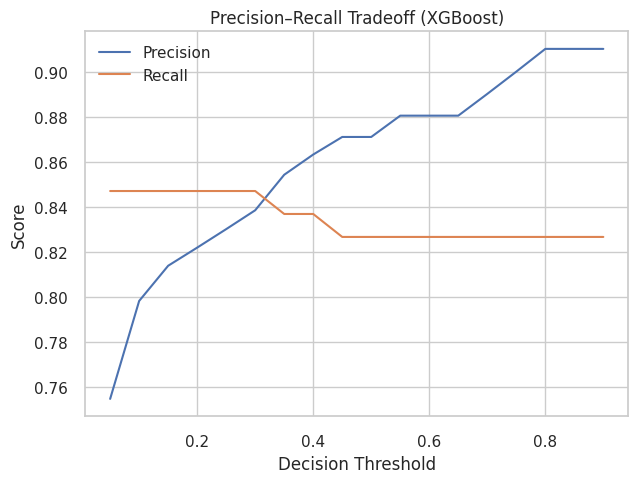

In [ ]:
thresholds = np.arange(0.05, 0.95, 0.05)

precision_list = []
recall_list = []

for t in thresholds:
    y_pred_thresh = (y_prob_xgb >= t).astype(int)
    precision_list.append(precision_score(y_test, y_pred_thresh, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_thresh, zero_division=0))

plt.figure(figsize=(7,5))
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Tradeoff (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()
